In [1]:
import os
import sys
import pandas as pd
import numpy as np
import missingno
import csv

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)

from utils import *

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import missingno
import csv

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)

from utils import *

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Attica'

In [4]:
base_path = f'../../data/{NUTS2}/results/'

In [5]:
file_list = os.listdir(base_path)
file_list.sort()
file_list

['GR_Attica_Results_2010-2022.csv',
 'GR_Attica_Results_2023-August-1st.csv',
 'GR_Attica_Results_2023-August-1st_(new).csv',
 'GR_Attica_Results_2023-July-1st.csv',
 'GR_Attica_Results_2023-July-1st_(new).csv',
 'GR_Attica_Results_2023-July-2nd.csv',
 'GR_Attica_Results_2023-July-2nd_(new).csv',
 'GR_Attica_Results_2023-June-1st.csv',
 'GR_Attica_Results_2023-June-1st_(new).csv',
 'GR_Attica_Results_2023-June-2nd.csv',
 'GR_Attica_Results_2023-June-2nd_(new).csv',
 'GR_Attica_Results_2023-May-1st.csv',
 'GR_Attica_Results_2023-May-1st_(new).csv',
 'GR_Attica_Results_2023-May-2nd.csv',
 'GR_Attica_Results_2023-May-2nd_(new).csv']

In [6]:
del file_list[1:15:2]

In [7]:
file_list

['GR_Attica_Results_2010-2022.csv',
 'GR_Attica_Results_2023-August-1st_(new).csv',
 'GR_Attica_Results_2023-July-1st_(new).csv',
 'GR_Attica_Results_2023-July-2nd_(new).csv',
 'GR_Attica_Results_2023-June-1st_(new).csv',
 'GR_Attica_Results_2023-June-2nd_(new).csv',
 'GR_Attica_Results_2023-May-1st_(new).csv',
 'GR_Attica_Results_2023-May-2nd_(new).csv']

In [8]:
result_files = []

for file in file_list:
    data = pd.read_csv(f'{base_path}/{file}', encoding='utf-8')
    result_files.append(data)

In [9]:
concated = pd.concat(result_files, ignore_index=True, axis = 0)

<AxesSubplot:>

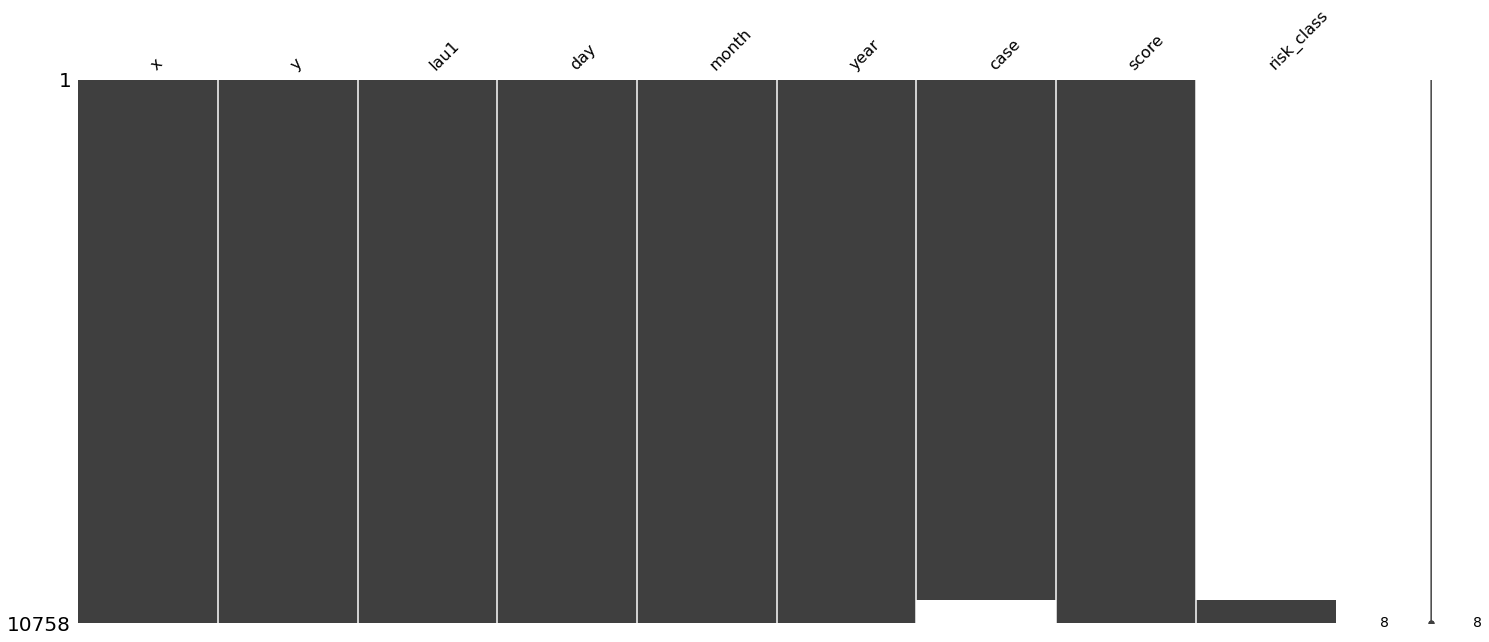

In [10]:
missingno.matrix(concated)

In [11]:
days = np.sort(concated.day.unique())
days

array([ 1, 16], dtype=int64)

In [12]:
months = np.sort(concated.month.unique())
months

array([ 5,  6,  7,  8,  9, 10], dtype=int64)

In [13]:
years = np.sort(concated.year.unique())
years

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023], dtype=int64)

In [14]:
df = concated[(concated['month'] >= 5) & (concated['month'] <= 8)].copy()

In [15]:
condition = df[(df['month'] == 8) & (df['day'] == 16)].index
df.drop(condition, inplace = True)
df

,x,y,lau1,day,month,year,case,score,risk_class
0,23.47721,37.48420,πορου,1,8,2019,0.0,0.999806,NaN
3,23.47721,37.48420,πορου,16,7,2019,0.0,0.999574,NaN
4,23.47721,37.48420,πορου,1,7,2019,0.0,0.999172,NaN
6,23.47721,37.48420,πορου,16,6,2019,0.0,0.996722,NaN
8,23.96791,37.97104,σπατων αρτεμιδος,1,8,2012,0.0,0.993113,NaN
...,...,...,...,...,...,...,...,...,...
10753,23.80511,37.99143,παπαγου χολαργου,16,5,2023,NaN,0.601696,3.0
10754,23.34009,37.69503,αγκιστριου,16,5,2023,NaN,0.561954,2.0
10755,23.43348,37.33221,υδρας,16,5,2023,NaN,0.154287,1.0
10756,23.79175,37.96013,καισαριανης,16,5,2023,NaN,0.017713,0.0


In [16]:
bins_path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Bins_2023.csv'

bins = []

with open(bins_path, mode='r', newline='') as file:
    reader = csv.reader(file)
    for row in reader:
        bins.extend(map(float, row))

print(bins)

[0.0, 0.0551293142597989, 0.309017870770514, 0.5848636387272795, 0.864260171276974, 0.9864932650737608, 1.0]


In [17]:
df['risk_class'] = pd.cut(df['score'], bins=bins, labels=False, include_lowest=True)
df.head(10)

,x,y,lau1,day,month,year,case,score,risk_class
0,23.47721,37.48420,πορου,1,8,2019,0.0,0.999806,5
3,23.47721,37.48420,πορου,16,7,2019,0.0,0.999574,5
4,23.47721,37.48420,πορου,1,7,2019,0.0,0.999172,5
6,23.47721,37.48420,πορου,16,6,2019,0.0,0.996722,5
8,23.96791,37.97104,σπατων αρτεμιδος,1,8,2012,0.0,0.993113,5
9,23.96791,37.97104,σπατων αρτεμιδος,1,8,2013,0.0,0.992625,5
13,23.87889,38.01188,παλληνης,1,8,2012,0.0,0.988906,5
17,24.02460,37.76124,λαυρεωτικης,1,8,2012,0.0,0.987226,5
18,24.02460,37.76124,λαυρεωτικης,1,8,2015,0.0,0.986493,4
19,24.02460,37.76124,λαυρεωτικης,1,8,2013,0.0,0.986362,4


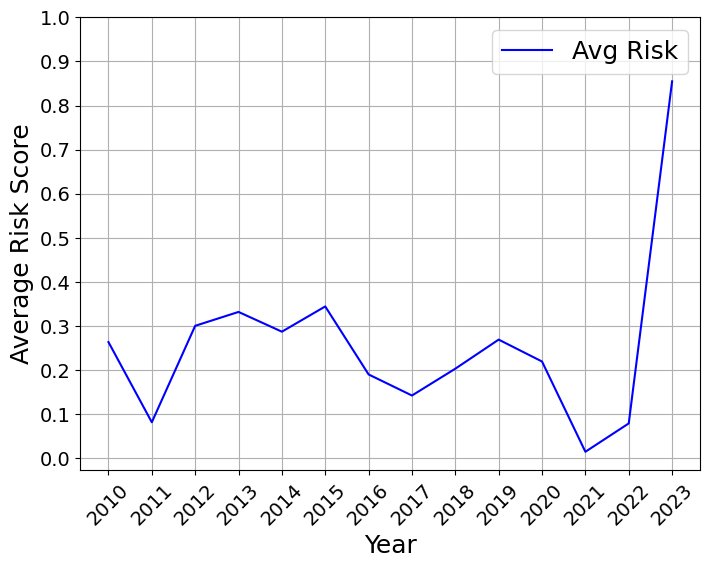

In [18]:
plot_trend_curve(df, plot_max = False, score_col = 'score', plot_cases=False, y_label='Average Risk Score')

In [19]:
risk_2022_over_7 = df[(df['year'] == 2022) & (df['risk_class'] >= 4)].copy()
risk_2022_over_7.reset_index(drop = True, inplace = True)
risk_2022_over_7

,x,y,lau1,day,month,year,case,score,risk_class


In [20]:
risk_2023_over_7 = df[(df['year'] == 2023) & (df['risk_class'] >= 4)].copy()
risk_2023_over_7.reset_index(drop = True, inplace = True)
risk_2023_over_7

,x,y,lau1,day,month,year,case,score,risk_class
0,23.36970,38.14150,μανδρας ειδυλλιας,1,8,2023,NaN,0.999084,5
1,23.26333,38.03007,μεγαρεων,1,8,2023,NaN,0.998711,5
2,23.75954,38.03728,νεας ιωνιας,1,8,2023,NaN,0.998447,5
3,23.75137,37.90259,ελληνικου αργυρουπολης,1,8,2023,NaN,0.998256,5
4,23.49864,37.73843,αιγινας,1,8,2023,NaN,0.996823,5
...,...,...,...,...,...,...,...,...,...
331,23.75743,38.16222,αχαρνων,16,5,2023,NaN,0.932110,4
332,23.82642,38.00806,αγιας παρασκευης,16,5,2023,NaN,0.923955,4
333,23.93208,37.78569,σαρωνικου,16,5,2023,NaN,0.920337,4
334,23.75711,38.01915,γαλατσιου,16,5,2023,NaN,0.892545,4
